In [1]:
# CELL 1 — Setup & Config

import os
import cv2
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Hyperparameters
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 40

LEARNING_RATE = 3e-5 

# Class labels
CLASS_NAMES = ['glioma', 'meningioma', 'pituitary', 'no_tumor']
class_to_idx = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print("Class mapping:", class_to_idx)

Using device: cuda
Class mapping: {'glioma': 0, 'meningioma': 1, 'pituitary': 2, 'no_tumor': 3}


In [2]:
# CELL 2 — Dataset Paths

# Base directory (Kaggle-style)
BASE_DIR = "/kaggle/input/brisc2025/brisc2025"

# Segmentation paths
SEG_TRAIN_IMG = os.path.join(BASE_DIR, "segmentation_task", "train", "images")
SEG_TRAIN_MASK = os.path.join(BASE_DIR, "segmentation_task", "train", "masks")

SEG_VAL_IMG = os.path.join(BASE_DIR, "segmentation_task", "test", "images")
SEG_VAL_MASK = os.path.join(BASE_DIR, "segmentation_task", "test", "masks")

# Classification paths
CLS_TRAIN_DIR = os.path.join(BASE_DIR, "classification_task", "train")
CLS_VAL_DIR = os.path.join(BASE_DIR, "classification_task", "test")

# Sanity checks
print("\n PATH CHECKS ")
print("SEG_TRAIN_IMG exists:", os.path.exists(SEG_TRAIN_IMG))
print("SEG_TRAIN_MASK exists:", os.path.exists(SEG_TRAIN_MASK))
print("SEG_VAL_IMG exists:", os.path.exists(SEG_VAL_IMG))
print("SEG_VAL_MASK exists:", os.path.exists(SEG_VAL_MASK))
print("CLS_TRAIN_DIR exists:", os.path.exists(CLS_TRAIN_DIR))
print("CLS_VAL_DIR exists:", os.path.exists(CLS_VAL_DIR))

print("\nSEGMENTATION COUNTS")
print("Train images:", len(os.listdir(SEG_TRAIN_IMG)))
print("Train masks :", len(os.listdir(SEG_TRAIN_MASK)))
print("Val images  :", len(os.listdir(SEG_VAL_IMG)))
print("Val masks   :", len(os.listdir(SEG_VAL_MASK)))

print("\nCLASSIFICATION CLASSES ")
print("Train classes:", os.listdir(CLS_TRAIN_DIR))
print("Val classes  :", os.listdir(CLS_VAL_DIR))


 PATH CHECKS 
SEG_TRAIN_IMG exists: True
SEG_TRAIN_MASK exists: True
SEG_VAL_IMG exists: True
SEG_VAL_MASK exists: True
CLS_TRAIN_DIR exists: True
CLS_VAL_DIR exists: True

SEGMENTATION COUNTS
Train images: 3933
Train masks : 3933
Val images  : 860
Val masks   : 860

CLASSIFICATION CLASSES 
Train classes: ['pituitary', 'no_tumor', 'meningioma', 'glioma']
Val classes  : ['pituitary', 'no_tumor', 'meningioma', 'glioma']


In [3]:
# CELL 3 — Dataset Classes

from torch.utils.data import Dataset

# Segmentation Dataset
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(
            self.mask_dir,
            img_name.replace(".jpg", ".png")
        )

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.img_size)
        img = img / 255.0
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)

        # Load mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, self.img_size)
        mask = mask / 255.0
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return img, mask


# Classification Dataset
class ClassificationDataset(Dataset):
    def __init__(self, root_dir, img_size):
        self.root_dir = root_dir
        self.img_size = img_size
        self.samples = []

        for cls_name in os.listdir(root_dir):
            cls_path = os.path.join(root_dir, cls_name)
            for img_name in os.listdir(cls_path):
                self.samples.append((cls_name, img_name))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        cls_name, img_name = self.samples[idx]
        img_path = os.path.join(self.root_dir, cls_name, img_name)

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.img_size)
        img = img / 255.0
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)

        label = class_to_idx[cls_name]

        return img, label

In [4]:
# CELL 4 — Data Splits

from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# Helper split function
def train_val_split(dataset, val_ratio=0.2, seed=42):
    indices = list(range(len(dataset)))
    train_idx, val_idx = train_test_split(
        indices,
        test_size=val_ratio,
        random_state=seed,
        shuffle=True
    )
    return train_idx, val_idx


# SEGMENTATION DATASETS
# Full TRAIN segmentation dataset
seg_train_full = SegmentationDataset(
    SEG_TRAIN_IMG,
    SEG_TRAIN_MASK,
    IMG_SIZE
)

seg_train_idx, seg_val_idx = train_val_split(seg_train_full, val_ratio=0.2)

seg_train_dataset = Subset(seg_train_full, seg_train_idx)
seg_val_dataset   = Subset(seg_train_full, seg_val_idx)

# TEST segmentation dataset (untouched)
seg_test_dataset = SegmentationDataset(
    SEG_VAL_IMG,
    SEG_VAL_MASK,
    IMG_SIZE
)

# CLASSIFICATION DATASETS

# Full TRAIN classification dataset
cls_train_full = ClassificationDataset(
    CLS_TRAIN_DIR,
    IMG_SIZE
)

# Split TRAIN → Train / Val
cls_train_idx, cls_val_idx = train_val_split(cls_train_full, val_ratio=0.2)

cls_train_dataset = Subset(cls_train_full, cls_train_idx)
cls_val_dataset   = Subset(cls_train_full, cls_val_idx)

# TEST classification dataset (untouched)
cls_test_dataset = ClassificationDataset(
    CLS_VAL_DIR,
    IMG_SIZE
)

# DATALOADERS

seg_train_loader = DataLoader(
    seg_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

seg_val_loader = DataLoader(
    seg_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

seg_test_loader = DataLoader(
    seg_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

cls_train_loader = DataLoader(
    cls_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

cls_val_loader = DataLoader(
    cls_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

cls_test_loader = DataLoader(
    cls_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# VERIFICATION
print("SEGMENTATION")
print("Train:", len(seg_train_dataset))
print("Val  :", len(seg_val_dataset))
print("Test :", len(seg_test_dataset))

print("\nCLASSIFICATION ")
print("Train:", len(cls_train_dataset))
print("Val  :", len(cls_val_dataset))
print("Test :", len(cls_test_dataset))

SEGMENTATION
Train: 3146
Val  : 787
Test : 860

CLASSIFICATION 
Train: 4000
Val  : 1000
Test : 1000


In [5]:
# CELL 5 — Losses & Metrics

# Dice Loss
def dice_loss(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    dice = (2. * intersection + smooth) / (
        preds.sum() + targets.sum() + smooth
    )
    return 1 - dice


# Dice Score (Metric)
def dice_score(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    dice = (2. * intersection + smooth) / (
        preds.sum() + targets.sum() + smooth
    )
    return dice


# IoU Score (Metric)
def iou_score(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou


# Tversky Loss (IMPROVES IoU/Dice)
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)

        TP = (preds * targets).sum()
        FP = ((1 - targets) * preds).sum()
        FN = (targets * (1 - preds)).sum()

        tversky = (TP + self.smooth) / (
            TP + self.alpha * FP + self.beta * FN + self.smooth
        )

        return 1 - tversky


# BCE Loss
bce_loss = nn.BCEWithLogitsLoss()

# Classification Loss
cls_loss = nn.CrossEntropyLoss()

# Instantiate Tversky
tversky_loss = TverskyLoss(alpha=0.3, beta=0.7)

print("Loss functions & metrics ready.")

Loss functions & metrics ready.


In [6]:
# CELL 6 — ResUNet++ Model

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.skip = nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, x):
        identity = self.skip(x)
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return torch.relu(out)


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.res = ResidualBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.res(x)


class ResUNetPP(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # Encoder
        self.e1 = ResidualBlock(3, 32)
        self.e2 = ResidualBlock(32, 64)
        self.e3 = ResidualBlock(64, 128)
        self.e4 = ResidualBlock(128, 256)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ResidualBlock(256, 512)

        # Decoder
        self.d4 = UpBlock(512, 256, 256)
        self.d3 = UpBlock(256, 128, 128)
        self.d2 = UpBlock(128, 64, 64)
        self.d1 = UpBlock(64, 32, 32)

        # Segmentation head
        self.seg_head = nn.Conv2d(32, 1, kernel_size=1)

        # Classification head
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        # Segmentation decoder
        d4 = self.d4(b, e4)
        d3 = self.d3(d4, e3)
        d2 = self.d2(d3, e2)
        d1 = self.d1(d2, e1)

        seg_out = self.seg_head(d1)

        # Classification output 
        cls_out = self.cls_head(b)

        return seg_out, cls_out

In [7]:
# CELL 7 — Optimizer & Scheduler

# Model initialization
model = ResUNetPP(num_classes=len(CLASS_NAMES)).to(device)

# Optimizer (reduced LR)
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=3e-5
)

# Scheduler (helps Dice/IoU)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',          
    factor=0.5,
    patience=3,
    verbose=True
)

print("Model, optimizer, and scheduler initialized.")

Model, optimizer, and scheduler initialized.


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [8]:
# CELL 8 — Training & Validation 

from tqdm import tqdm

best_combined = 0.0

# Logging containers
train_total_losses = []
val_total_losses = []

train_seg_losses = []
train_cls_losses = []

val_dice_scores = []
val_iou_scores = []
val_acc_scores = []

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    # TRAINING
    model.train()

    seg_loss_sum = 0.0
    cls_loss_sum = 0.0

    # ---- Segmentation training ----
    seg_loop = tqdm(seg_train_loader, desc="Segmentation Train")
    for imgs, masks in seg_loop:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        seg_out, _ = model(imgs)

        seg_loss = dice_loss(seg_out, masks) + tversky_loss(seg_out, masks)
        seg_loss.backward()
        optimizer.step()

        seg_loss_sum += seg_loss.item()
        seg_loop.set_postfix(seg_loss=seg_loss.item())

    avg_seg_loss = seg_loss_sum / len(seg_train_loader)

    # ---- Classification training ----
    cls_loop = tqdm(cls_train_loader, desc="Classification Train")
    for imgs, labels in cls_loop:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        _, cls_out = model(imgs)

        cls_loss_val = cls_loss(cls_out, labels)
        cls_loss_val.backward()
        optimizer.step()

        cls_loss_sum += cls_loss_val.item()
        cls_loop.set_postfix(cls_loss=cls_loss_val.item())

    avg_cls_loss = cls_loss_sum / len(cls_train_loader)

    # VALIDATION
    model.eval()

    dice_sum, iou_sum = 0.0, 0.0
    seg_batches = 0

    all_preds, all_labels = [], []

    with torch.no_grad():
        # ---- Segmentation validation ----
        for imgs, masks in seg_val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            seg_out, _ = model(imgs)

            dice_sum += dice_score(seg_out, masks).item()
            iou_sum  += iou_score(seg_out, masks).item()
            seg_batches += 1

        # ---- Classification validation ----
        for imgs, labels in cls_val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            _, cls_out = model(imgs)

            preds = torch.argmax(cls_out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    dice_avg = dice_sum / seg_batches
    iou_avg  = iou_sum / seg_batches
    acc      = accuracy_score(all_labels, all_preds)

    # Scheduler step (Dice)
    scheduler.step(dice_avg)

    # Combined score (YOUR LOGIC)
    combined_score = (dice_avg + iou_avg + acc) / 3

    # Logging
    train_seg_losses.append(avg_seg_loss)
    train_cls_losses.append(avg_cls_loss)
    train_total_losses.append(avg_seg_loss + avg_cls_loss)

    val_dice_scores.append(dice_avg)
    val_iou_scores.append(iou_avg)
    val_acc_scores.append(acc)
    val_total_losses.append(1 - dice_avg)

    print(f"Seg Loss     : {avg_seg_loss:.4f}")
    print(f"Cls Loss     : {avg_cls_loss:.4f}")
    print(f"Dice Score   : {dice_avg:.4f}")
    print(f"IoU Score    : {iou_avg:.4f}")
    print(f"Accuracy     : {acc:.4f}")
    print(f"Combined     : {combined_score:.4f}")

    # Save best model (COMBINED)
    if combined_score > best_combined:
        best_combined = combined_score
        torch.save(model.state_dict(), "best_resunetpp_multitask.pth")
        print("Best model saved!")


Epoch [1/40]


Classification Train: 100%|██████████| 500/500 [00:31<00:00, 16.01it/s, cls_loss=0.842]


Seg Loss     : 1.5839
Cls Loss     : 0.7348
Dice Score   : 0.4256
IoU Score    : 0.2839
Accuracy     : 0.7750
Combined     : 0.4948
Best model saved!

Epoch [2/40]


Classification Train: 100%|██████████| 500/500 [00:30<00:00, 16.19it/s, cls_loss=0.55]  


Seg Loss     : 0.6258
Cls Loss     : 0.4620
Dice Score   : 0.6771
IoU Score    : 0.5273
Accuracy     : 0.8370
Combined     : 0.6805
Best model saved!

Epoch [3/40]


...

Seg Loss     : 0.1088
Cls Loss     : 0.0041
Dice Score   : 0.8422
IoU Score    : 0.7338
Accuracy     : 0.9820
Combined     : 0.8526
Best model saved!

Epoch [39/40]


Classification Train: 100%|██████████| 500/500 [00:31<00:00, 16.12it/s, cls_loss=0.00211] 


Seg Loss     : 0.1055
Cls Loss     : 0.0046
Dice Score   : 0.8382
IoU Score    : 0.7296
Accuracy     : 0.9760
Combined     : 0.8479

Epoch [40/40]


Classification Train: 100%|██████████| 500/500 [00:31<00:00, 16.05it/s, cls_loss=0.000121]


Seg Loss     : 0.1028
Cls Loss     : 0.0029
Dice Score   : 0.8407
IoU Score    : 0.7330
Accuracy     : 0.9790
Combined     : 0.8509


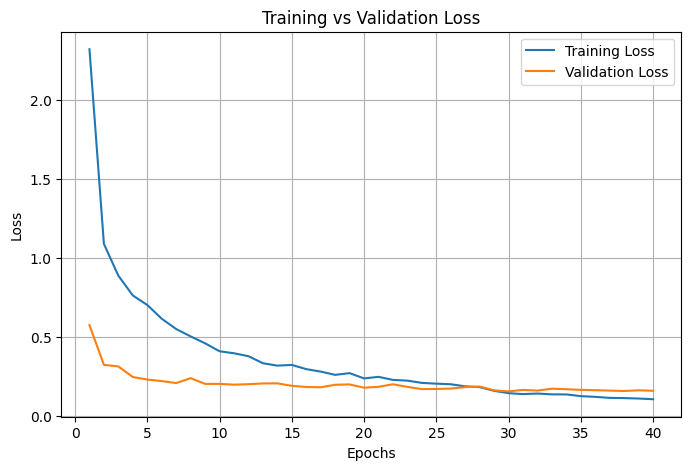

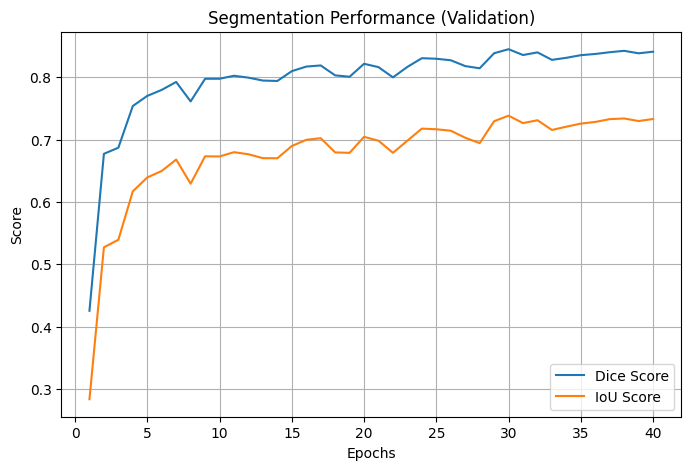

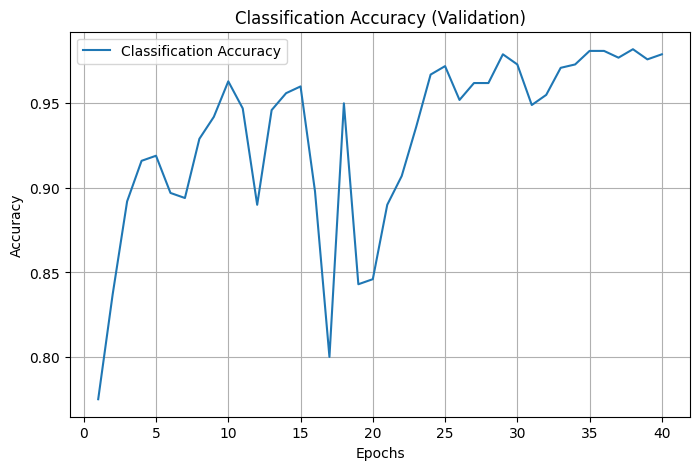

In [9]:
# CELL 9 — Training Curves

epochs = range(1, len(train_total_losses) + 1)

# Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_total_losses, label="Training Loss")
plt.plot(epochs, val_total_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


#  Segmentation Dice & IoU
plt.figure(figsize=(8, 5))
plt.plot(epochs, val_dice_scores, label="Dice Score")
plt.plot(epochs, val_iou_scores, label="IoU Score")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("Segmentation Performance (Validation)")
plt.legend()
plt.grid(True)
plt.show()


#  Classification Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, val_acc_scores, label="Classification Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy (Validation)")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# CELL 10 — Load Best Model

MODEL_PATH = "best_resunetpp_multitask.pth"

# Load weights
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

# Set to evaluation mode
model.eval()

print("Best model loaded successfully.")
print("Model ready for testing.")

Best model loaded successfully.
Model ready for testing.


In [11]:
# MANUAL SAVE (AFTER TRAINING)

MODEL_PATH = "/kaggle/working/best_resunetpp_multitask.pth"

torch.save(model.state_dict(), MODEL_PATH)

print(f"Model manually saved at: {MODEL_PATH}")

Model manually saved at: /kaggle/working/best_resunetpp_multitask.pth


In [12]:
# CELL 11 — FINAL TESTING

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

# SEGMENTATION TESTING
dice_sum, iou_sum = 0.0, 0.0
tp = tn = fp = fn = 0
seg_batches = 0

with torch.no_grad():
    for imgs, masks in tqdm(seg_test_loader, desc="Segmentation Testing"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        seg_out, _ = model(imgs)

        probs = torch.sigmoid(seg_out)
        preds = (probs > 0.5).int()
        gt = (masks > 0.5).int()

        dice_sum += dice_score(seg_out, masks).item()
        iou_sum  += iou_score(seg_out, masks).item()
        seg_batches += 1

        tp += ((preds == 1) & (gt == 1)).sum().item()
        tn += ((preds == 0) & (gt == 0)).sum().item()
        fp += ((preds == 1) & (gt == 0)).sum().item()
        fn += ((preds == 0) & (gt == 1)).sum().item()

dice_test = dice_sum / seg_batches
iou_test  = iou_sum / seg_batches
seg_accuracy = (tp + tn) / (tp + tn + fp + fn)


# CLASSIFICATION TESTING
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tqdm(cls_test_loader, desc="Classification Testing"):
        imgs = imgs.to(device)
        labels = labels.to(device)

        _, cls_out = model(imgs)
        preds = torch.argmax(cls_out, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
rec  = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)

# PRINT FINAL RESULTS
print("\nFINAL TEST RESULTS n")

print("Segmentation (Test Set)")
print(f"Dice Score        : {dice_test:.4f}")
print(f"IoU Score         : {iou_test:.4f}")
print(f"Segmentation Acc  : {seg_accuracy:.4f}\n")

print("Classification (Test Set)")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")



Classification Testing: 100%|██████████| 125/125 [00:07<00:00, 17.54it/s]



FINAL TEST RESULTS n
Segmentation (Test Set)
Dice Score        : 0.8432
IoU Score         : 0.7433
Segmentation Acc  : 0.9950

Classification (Test Set)
Accuracy  : 0.9810
Precision : 0.9780
Recall    : 0.9831
F1-score  : 0.9804


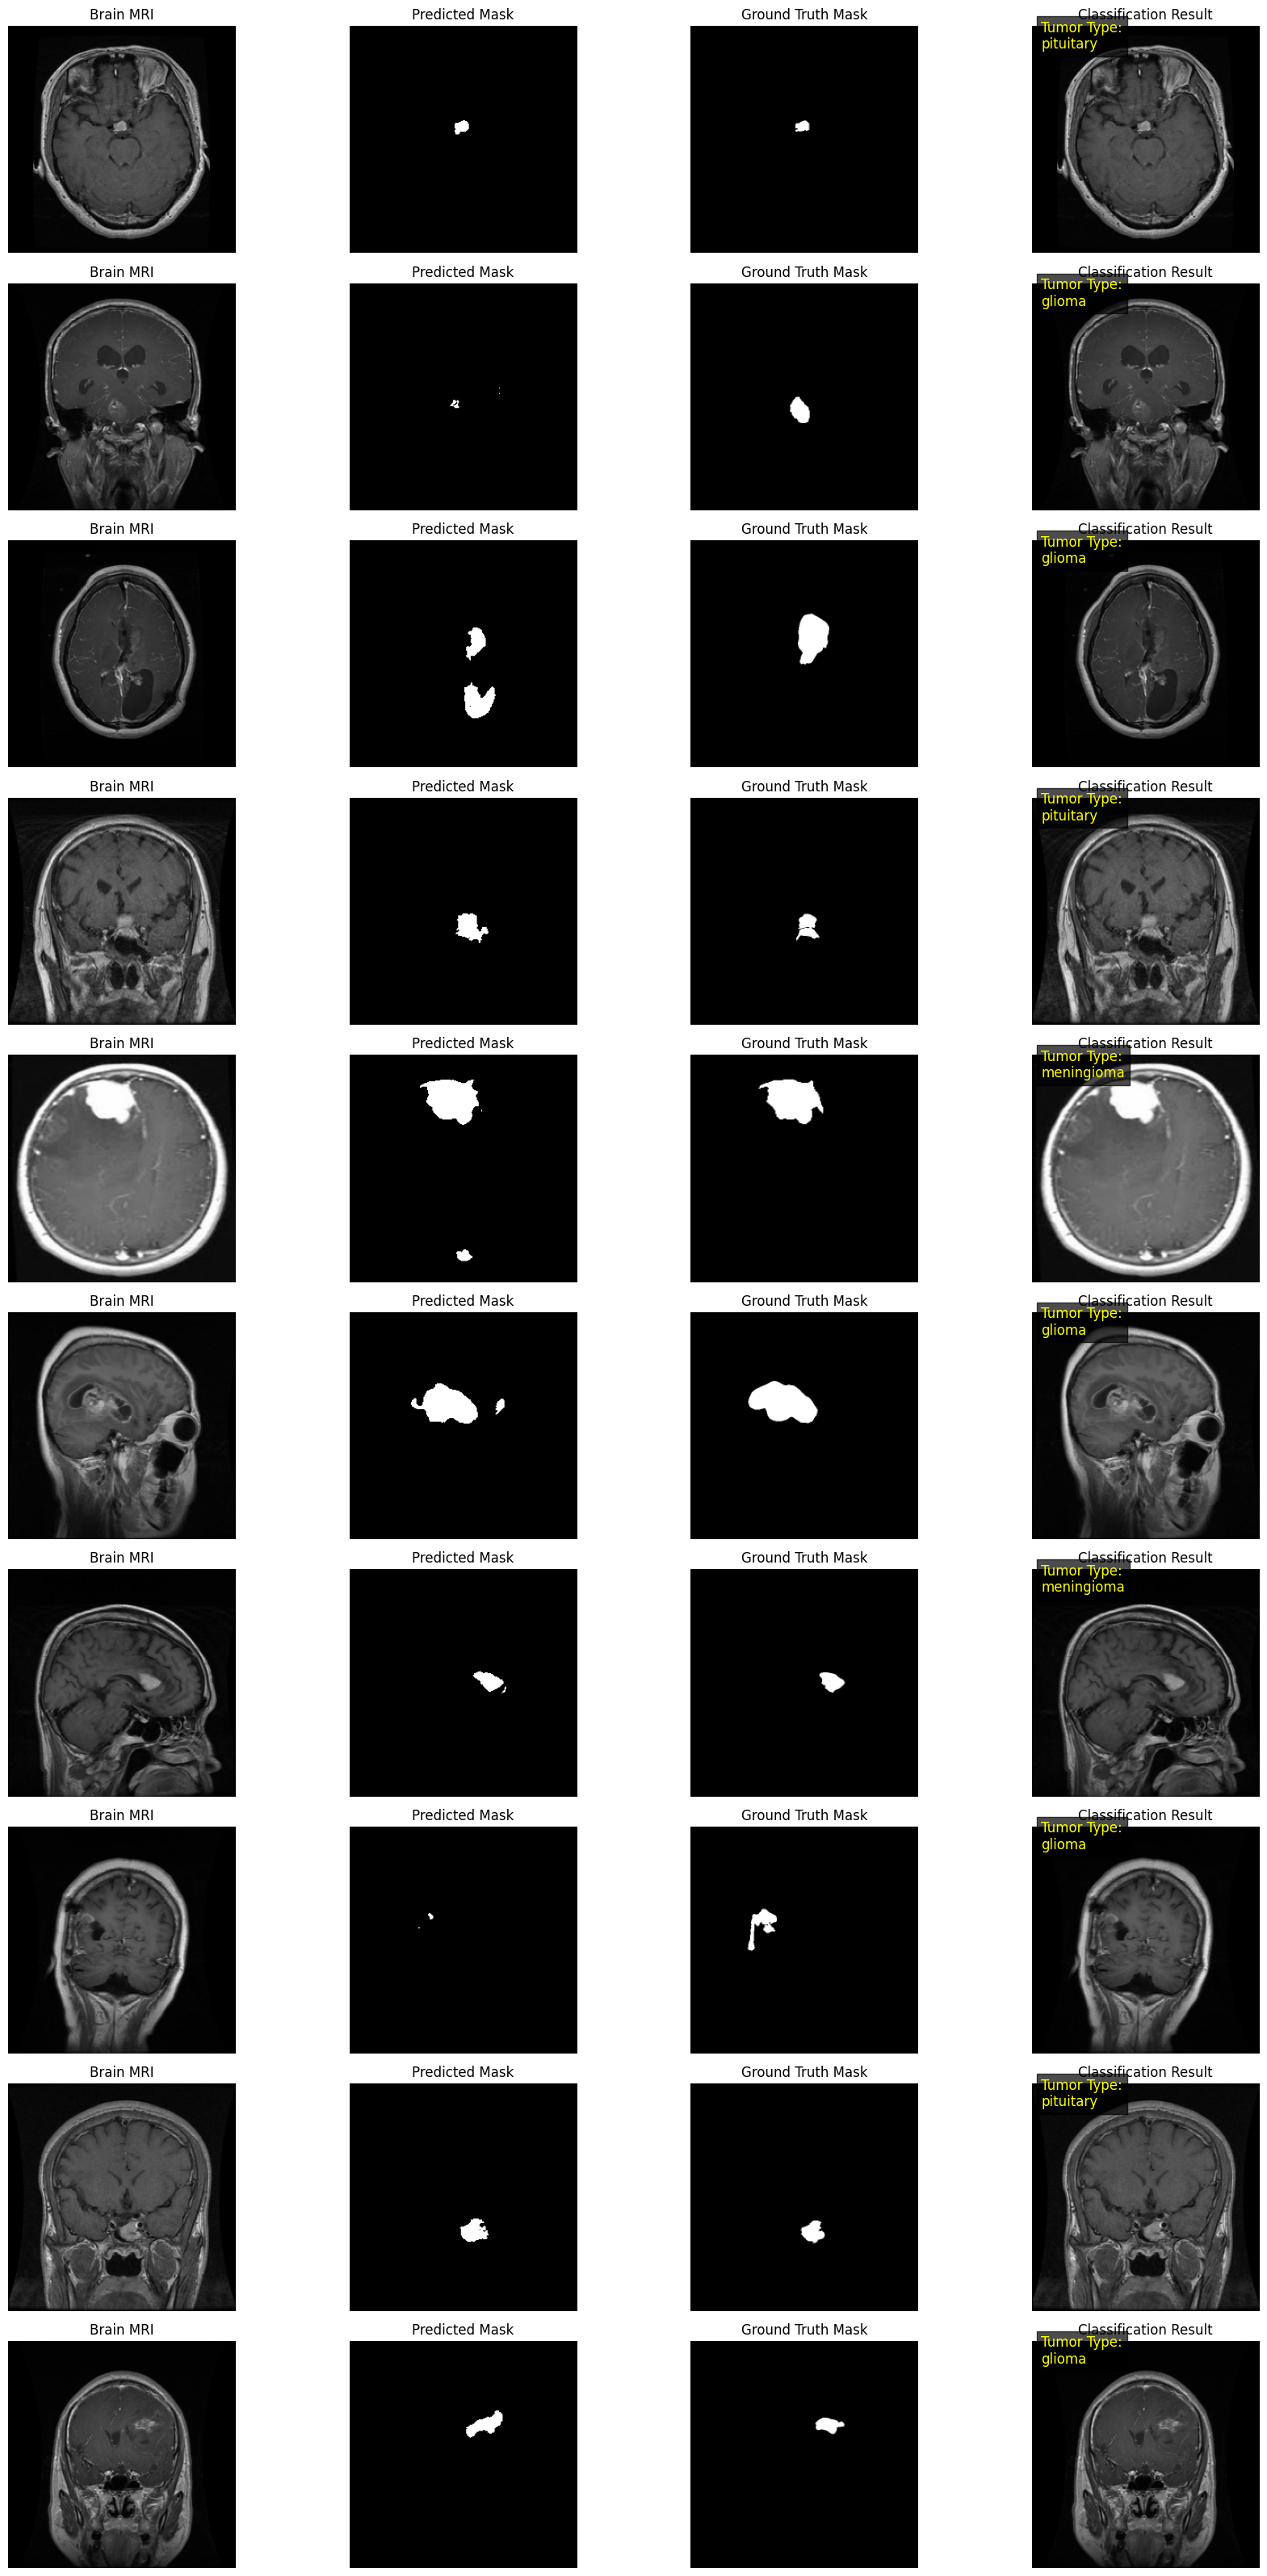

In [13]:
# VISUAL RESULTS — 4 COLUMN TABLE

import random
import matplotlib.pyplot as plt

model.eval()

num_samples = 10
indices = random.sample(range(len(seg_test_dataset)), num_samples)

plt.figure(figsize=(18, 32))

for i, idx in enumerate(indices):
    # Load segmentation sample 
    img, gt_mask = seg_test_dataset[idx]
    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        seg_pred, cls_pred = model(img)
        seg_pred = (torch.sigmoid(seg_pred) > 0.5).cpu().squeeze()
        cls_label = torch.argmax(cls_pred, dim=1).item()

    tumor_label = idx_to_class[cls_label]

    # Convert image for display
    img_disp = img.cpu().squeeze().permute(1, 2, 0)

    #  COLUMN 1: MRI IMAGE 
    plt.subplot(num_samples, 4, i*4 + 1)
    plt.imshow(img_disp, cmap="gray")
    plt.title("Brain MRI")
    plt.axis("off")

    #  COLUMN 2: PREDICTED MASK 
    plt.subplot(num_samples, 4, i*4 + 2)
    plt.imshow(seg_pred, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    # COLUMN 3: GROUND TRUTH MASK 
    plt.subplot(num_samples, 4, i*4 + 3)
    plt.imshow(gt_mask.squeeze(), cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    # COLUMN 4: MRI + TUMOR TYPE
    plt.subplot(num_samples, 4, i*4 + 4)
    plt.imshow(img_disp, cmap="gray")
    plt.text(
        10, 25,
        f"Tumor Type:\n{tumor_label}",
        fontsize=12,
        color="yellow",
        bbox=dict(facecolor="black", alpha=0.7)
    )
    plt.title("Classification Result")
    plt.axis("off")

plt.tight_layout()
plt.show()

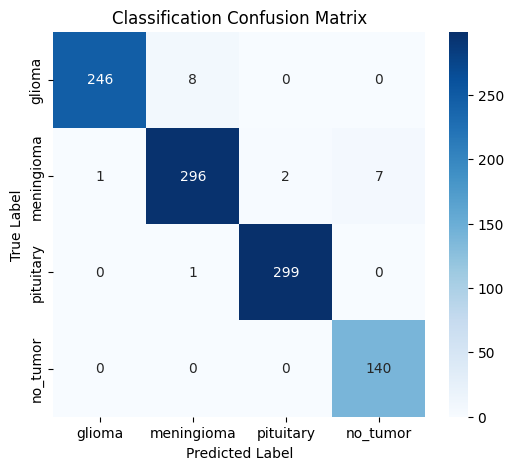

Segmentation Confusion: 100%|██████████| 108/108 [00:03<00:00, 27.64it/s]


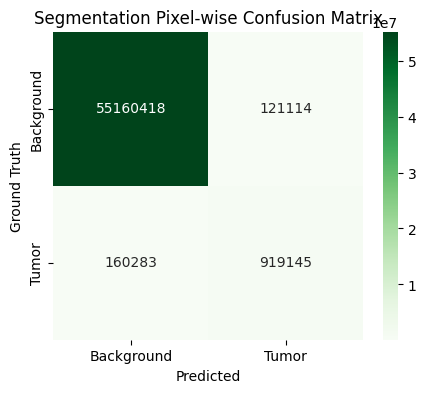

In [14]:
# CELL 12 — Confusion Matrices

import seaborn as sns

# CLASSIFICATION CONFUSION MATRIX (4 × 4)

cm_cls = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_cls,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Classification Confusion Matrix")
plt.show()


#  SEGMENTATION CONFUSION MATRIX (PIXEL-WISE, 2 × 2)

tp = fp = tn = fn = 0

with torch.no_grad():
    for imgs, masks in tqdm(seg_test_loader, desc="Segmentation Confusion"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        seg_out, _ = model(imgs)
        preds = (torch.sigmoid(seg_out) > 0.5).int()
        gt = (masks > 0.5).int()

        tp += ((preds == 1) & (gt == 1)).sum().item()
        tn += ((preds == 0) & (gt == 0)).sum().item()
        fp += ((preds == 1) & (gt == 0)).sum().item()
        fn += ((preds == 0) & (gt == 1)).sum().item()

cm_seg = np.array([[tn, fp],
                   [fn, tp]])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_seg,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Background", "Tumor"],
    yticklabels=["Background", "Tumor"]
)

plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Segmentation Pixel-wise Confusion Matrix")
plt.show()

In [15]:

import os
import json
import shutil
import zipfile
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0. Export root + subfolders
EXPORT_ROOT = "/kaggle/working/export" if os.path.isdir("/kaggle/working") else "./export"

SUBDIRS = {
    "models":      os.path.join(EXPORT_ROOT, "models"),
    "history":     os.path.join(EXPORT_ROOT, "history"),
    "metrics":     os.path.join(EXPORT_ROOT, "metrics"),
    "plots":       os.path.join(EXPORT_ROOT, "plots"),
    "predictions": os.path.join(EXPORT_ROOT, "predictions"),
    "config":      os.path.join(EXPORT_ROOT, "config"),
}

for d in SUBDIRS.values():
    os.makedirs(d, exist_ok=True)

print(f"Export root: {EXPORT_ROOT}")


def _g(name, default=None):
    """Safely fetch a notebook variable from the global namespace if it exists."""
    return globals()[name] if name in globals() else default


def _save(msg, fn):
    """Run fn(), print success/failure, never raise."""
    try:
        fn()
        print(f"  [OK]   {msg}")
    except Exception as e:
        print(f"  [SKIP] {msg} -> {e}")


# 1. Model weights / checkpoints

_model = _g("model")

# Copy the best checkpoint saved during training, if it exists on disk
for candidate in ["best_resunetpp_multitask.pth",
                   "/kaggle/working/best_resunetpp_multitask.pth"]:
    if os.path.exists(candidate):
        _save(
            f"copy best checkpoint from {candidate}",
            lambda c=candidate: shutil.copy(
                c, os.path.join(SUBDIRS["models"], "best_resunetpp_multitask.pth")
            ),
        )
        break

# Save the current in-memory model state (after CELL 10 this is the best model,
# reloaded from disk) as the "final" model for reproducibility.
if _model is not None:
    import torch
    _save(
        "save final in-memory model state_dict",
        lambda: torch.save(
            _model.state_dict(),
            os.path.join(SUBDIRS["models"], "final_model_state_dict.pth"),
        ),
    )

    # Also save optimizer/scheduler state if still available (useful for resuming)
    _optimizer = _g("optimizer")
    _scheduler = _g("scheduler")
    if _optimizer is not None:
        _save(
            "save optimizer state_dict",
            lambda: torch.save(
                _optimizer.state_dict(),
                os.path.join(SUBDIRS["models"], "optimizer_state_dict.pth"),
            ),
        )
    if _scheduler is not None:
        _save(
            "save scheduler state_dict",
            lambda: torch.save(
                _scheduler.state_dict(),
                os.path.join(SUBDIRS["models"], "scheduler_state_dict.pth"),
            ),
        )
else:
    print("  [SKIP] `model` not found in memory.")



# 2. Training history (loss, Dice, IoU, accuracy)
print("\n--- Saving training history ---")

history_fields = {
    "train_total_loss": _g("train_total_losses"),
    "val_total_loss":   _g("val_total_losses"),
    "train_seg_loss":   _g("train_seg_losses"),
    "train_cls_loss":   _g("train_cls_losses"),
    "val_dice":         _g("val_dice_scores"),
    "val_iou":          _g("val_iou_scores"),
    "val_accuracy":     _g("val_acc_scores"),
}

available_history = {k: v for k, v in history_fields.items() if v is not None and len(v) > 0}

if available_history:
    max_len = max(len(v) for v in available_history.values())
    history_df = pd.DataFrame(
        {k: (v + [None] * (max_len - len(v))) for k, v in available_history.items()}
    )
    history_df.insert(0, "epoch", range(1, max_len + 1))

    _save(
        "write training_history.csv",
        lambda: history_df.to_csv(
            os.path.join(SUBDIRS["history"], "training_history.csv"), index=False
        ),
    )
    _save(
        "write training_history.json",
        lambda: history_df.to_json(
            os.path.join(SUBDIRS["history"], "training_history.json"), orient="records", indent=2
        ),
    )
else:
    print("  [SKIP] No training history lists found in memory.")

best_combined = _g("best_combined")
if best_combined is not None:
    _save(
        "write best_combined_score.json",
        lambda: json.dump(
            {"best_combined_score": float(best_combined)},
            open(os.path.join(SUBDIRS["history"], "best_combined_score.json"), "w"),
            indent=2,
        ),
    )


# 3. Final test evaluation metrics

test_metrics = {
    "segmentation": {
        "dice_score": _g("dice_test"),
        "iou_score":  _g("iou_test"),
        "pixel_accuracy": _g("seg_accuracy"),
    },
    "classification": {
        "accuracy":  _g("acc"),
        "precision_macro": _g("prec"),
        "recall_macro":    _g("rec"),
        "f1_macro":        _g("f1"),
    },
}

# Only keep sub-dicts that actually have at least one non-None value
test_metrics = {
    section: {k: v for k, v in vals.items() if v is not None}
    for section, vals in test_metrics.items()
}
test_metrics = {section: vals for section, vals in test_metrics.items() if vals}

if test_metrics:
    _save(
        "write test_metrics.json",
        lambda: json.dump(
            test_metrics,
            open(os.path.join(SUBDIRS["metrics"], "test_metrics.json"), "w"),
            indent=2,
        ),
    )

    def _write_metrics_txt():
        lines = ["FINAL TEST RESULTS \n"]
        if "segmentation" in test_metrics:
            lines.append("Segmentation (Test Set)")
            for k, v in test_metrics["segmentation"].items():
                lines.append(f"{k}: {v:.4f}")
            lines.append("")
        if "classification" in test_metrics:
            lines.append("Classification (Test Set)")
            for k, v in test_metrics["classification"].items():
                lines.append(f"{k}: {v:.4f}")
        with open(os.path.join(SUBDIRS["metrics"], "test_metrics.txt"), "w") as f:
            f.write("\n".join(lines))

    _save("write test_metrics.txt", _write_metrics_txt)
else:
    print("  [SKIP] No final test metrics found in memory.")

all_labels = _g("all_labels")
all_preds = _g("all_preds")
CLASS_NAMES = _g("CLASS_NAMES")

if all_labels is not None and all_preds is not None:
    def _write_cls_report():
        from sklearn.metrics import classification_report
        report = classification_report(
            all_labels, all_preds,
            target_names=CLASS_NAMES if CLASS_NAMES else None,
            zero_division=0,
        )
        with open(os.path.join(SUBDIRS["metrics"], "classification_report.txt"), "w") as f:
            f.write(report)

    _save("write classification_report.txt", _write_cls_report)


# 4. Confusion matrices (data + plots)

cm_cls = _g("cm_cls")
cm_seg = _g("cm_seg")

if cm_cls is not None:
    _save(
        "save classification confusion matrix (csv)",
        lambda: pd.DataFrame(
            cm_cls,
            index=CLASS_NAMES if CLASS_NAMES else None,
            columns=CLASS_NAMES if CLASS_NAMES else None,
        ).to_csv(os.path.join(SUBDIRS["metrics"], "confusion_matrix_classification.csv")),
    )

    def _plot_cm_cls():
        import seaborn as sns
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm_cls, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        )
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title("Classification Confusion Matrix")
        plt.tight_layout()
        plt.savefig(os.path.join(SUBDIRS["plots"], "confusion_matrix_classification.png"), dpi=150)
        plt.close()

    _save("plot classification confusion matrix", _plot_cm_cls)

if cm_seg is not None:
    _save(
        "save segmentation confusion matrix (csv)",
        lambda: pd.DataFrame(
            cm_seg,
            index=["Background", "Tumor"],
            columns=["Background", "Tumor"],
        ).to_csv(os.path.join(SUBDIRS["metrics"], "confusion_matrix_segmentation.csv")),
    )

    def _plot_cm_seg():
        import seaborn as sns
        plt.figure(figsize=(5, 4))
        sns.heatmap(
            cm_seg, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Background", "Tumor"], yticklabels=["Background", "Tumor"],
        )
        plt.xlabel("Predicted")
        plt.ylabel("Ground Truth")
        plt.title("Segmentation Pixel-wise Confusion Matrix")
        plt.tight_layout()
        plt.savefig(os.path.join(SUBDIRS["plots"], "confusion_matrix_segmentation.png"), dpi=150)
        plt.close()

    _save("plot segmentation confusion matrix", _plot_cm_seg)




if _g("train_total_losses") and _g("val_total_losses"):
    def _plot_loss():
        ep = range(1, len(train_total_losses) + 1)
        plt.figure(figsize=(8, 5))
        plt.plot(ep, train_total_losses, label="Training Loss")
        plt.plot(ep, val_total_losses, label="Validation Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Training vs Validation Loss")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(SUBDIRS["plots"], "loss_curve.png"), dpi=150)
        plt.close()

    _save("plot loss curve", _plot_loss)

if _g("val_dice_scores") and _g("val_iou_scores"):
    def _plot_dice_iou():
        ep = range(1, len(val_dice_scores) + 1)
        plt.figure(figsize=(8, 5))
        plt.plot(ep, val_dice_scores, label="Dice Score")
        plt.plot(ep, val_iou_scores, label="IoU Score")
        plt.xlabel("Epochs")
        plt.ylabel("Score")
        plt.title("Segmentation Performance (Validation)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(SUBDIRS["plots"], "dice_iou_curve.png"), dpi=150)
        plt.close()

    _save("plot Dice/IoU curve", _plot_dice_iou)

if _g("val_acc_scores"):
    def _plot_acc():
        ep = range(1, len(val_acc_scores) + 1)
        plt.figure(figsize=(8, 5))
        plt.plot(ep, val_acc_scores, label="Classification Accuracy")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.title("Classification Accuracy (Validation)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(SUBDIRS["plots"], "accuracy_curve.png"), dpi=150)
        plt.close()

    _save("plot accuracy curve", _plot_acc)



print("\nSaving sample predictions")

seg_test_dataset = _g("seg_test_dataset")
idx_to_class = _g("idx_to_class")

if _model is not None and seg_test_dataset is not None and idx_to_class is not None:
    def _save_predictions():
        import torch
        import random as _random

        device_local = _g("device")
        _model.eval()

        num_samples = min(10, len(seg_test_dataset))
        indices = _random.sample(range(len(seg_test_dataset)), num_samples)

        plt.figure(figsize=(18, 3.2 * num_samples))

        for i, idx in enumerate(indices):
            img, gt_mask = seg_test_dataset[idx]
            img_in = img.unsqueeze(0).to(device_local)

            with torch.no_grad():
                seg_pred, cls_pred = _model(img_in)
                seg_pred = (torch.sigmoid(seg_pred) > 0.5).cpu().squeeze()
                cls_label = torch.argmax(cls_pred, dim=1).item()

            tumor_label = idx_to_class[cls_label]
            img_disp = img_in.cpu().squeeze().permute(1, 2, 0)

            plt.subplot(num_samples, 4, i * 4 + 1)
            plt.imshow(img_disp, cmap="gray")
            plt.title("Brain MRI")
            plt.axis("off")

            plt.subplot(num_samples, 4, i * 4 + 2)
            plt.imshow(seg_pred, cmap="gray")
            plt.title("Predicted Mask")
            plt.axis("off")

            plt.subplot(num_samples, 4, i * 4 + 3)
            plt.imshow(gt_mask.squeeze(), cmap="gray")
            plt.title("Ground Truth Mask")
            plt.axis("off")

            plt.subplot(num_samples, 4, i * 4 + 4)
            plt.imshow(img_disp, cmap="gray")
            plt.text(
                10, 25, f"Tumor Type:\n{tumor_label}",
                fontsize=12, color="yellow",
                bbox=dict(facecolor="black", alpha=0.7),
            )
            plt.title("Classification Result")
            plt.axis("off")

        plt.tight_layout()
        plt.savefig(os.path.join(SUBDIRS["predictions"], "sample_predictions_grid.png"), dpi=150)
        plt.close()

    _save("generate & save sample predictions grid", _save_predictions)
else:
    print("  [SKIP] Missing model / seg_test_dataset / idx_to_class for sample predictions.")



print("\nSaving config ")

config = {
    "img_size": _g("IMG_SIZE"),
    "batch_size": _g("BATCH_SIZE"),
    "epochs": _g("EPOCHS"),
    "learning_rate": _g("LEARNING_RATE"),
    "class_names": _g("CLASS_NAMES"),
    "class_to_idx": _g("class_to_idx"),
    "seg_threshold": 0.5,
    "best_combined_score": _g("best_combined"),
    "model_architecture": "ResUNetPP (custom, multitask segmentation + classification)",
    "export_timestamp": datetime.now().isoformat(),
}
config = {k: v for k, v in config.items() if v is not None}

_save(
    "write config.json",
    lambda: json.dump(
        config, open(os.path.join(SUBDIRS["config"], "config.json"), "w"), indent=2, default=str
    ),
)




def _make_zip():
    zip_path = EXPORT_ROOT.rstrip("/") + ".zip"
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(EXPORT_ROOT):
            for file in files:
                fp = os.path.join(root, file)
                zf.write(fp, os.path.relpath(fp, os.path.dirname(EXPORT_ROOT)))
    print(f"  Zip created at: {zip_path}")


_save("zip export folder", _make_zip)



Export root: /kaggle/working/export
  [OK]   copy best checkpoint from best_resunetpp_multitask.pth
  [OK]   save final in-memory model state_dict
  [OK]   save optimizer state_dict
  [OK]   save scheduler state_dict

--- Saving training history ---
  [OK]   write training_history.csv
  [OK]   write training_history.json
  [OK]   write best_combined_score.json
  [OK]   write test_metrics.json
  [OK]   write test_metrics.txt
  [OK]   write classification_report.txt
  [OK]   save classification confusion matrix (csv)
  [OK]   plot classification confusion matrix
  [OK]   save segmentation confusion matrix (csv)
  [OK]   plot segmentation confusion matrix
  [OK]   plot loss curve
  [OK]   plot Dice/IoU curve
  [OK]   plot accuracy curve

Saving sample predictions
  [OK]   generate & save sample predictions grid

Saving config 
  [OK]   write config.json
  Zip created at: /kaggle/working/export.zip
  [OK]   zip export folder
